In [1]:
try:
    from google.colab import drive
    drive.mount('/gdrive')
    dataset_root = '/gdrive/MyDrive/datasets'
    !pip install torchinfo tqdm
    colab = True
except Exception as e:
    print(e)
    print('Assuming we\'re not on colab.')
    dataset_root = './datasets'
    colab = False

print('Will store datasets in', dataset_root)

import os

if os.name == 'nt':
    print("Disabling multiprocessing because we're running on windows.")
    cpu_num = 0
elif colab:
    cpu_num = 2
else:
    cpu_num = os.cpu_count() // 2
    print('Dataloaders will use {} CPUs'.format(cpu_num))

No module named 'google.colab'
Assuming we're not on colab.
Will store datasets in ./datasets
Dataloaders will use 12 CPUs


In [2]:
import random

import torch
import torch.utils.data as tud
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms.v2 as tv2
import torchvision.datasets as tds
import torchvision.utils as tu
import torchvision.ops as tvo
import torchvision

from torchinfo import summary
from tqdm import tqdm
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
COCO=False
VOC=True

In [41]:
# https://pytorch.org/vision/stable/auto_examples/transforms/plot_transforms_e2e.html
if COCO:
    nn_dim = (640, 640)
    train_tfs_v2 = tv2.Compose([
        tv2.ToImage(),
        tv2.RandomHorizontalFlip(0.5),
        tv2.RandomResizedCrop(nn_dim, antialias=True),
        tv2.SanitizeBoundingBoxes(),
        tv2.ToDtype(torch.float32, scale=True),
        tv2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    val_tfs_v2 = tv2.Compose([
        tv2.ToImage(),
        tv2.Resize(nn_dim, antialias=True),
        tv2.SanitizeBoundingBoxes(),
        tv2.ToDtype(torch.float32, scale=True),
        tv2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    img_train = tds.CocoDetection(
        root=dataset_root + '/coco/train2017/',
        annFile=dataset_root + '/coco/annotations/instances_train2017.json',
        transforms=train_tfs_v2
    )

    img_train = tds.wrap_dataset_for_transforms_v2(img_train)

    img_val = tds.CocoDetection(
        root=dataset_root + '/coco/val2017/',
        annFile=dataset_root + '/coco/annotations/instances_val2017.json',
        transforms=val_tfs_v2
    )
    img_val = tds.wrap_dataset_for_transforms_v2(img_val)
elif VOC:
    nn_dim = (640, 640)
    train_tfs_v2 = tv2.Compose([
        tv2.ToImage(),
        tv2.RandomHorizontalFlip(0.5),
        tv2.RandomResizedCrop(nn_dim, antialias=True),
        tv2.SanitizeBoundingBoxes(),
        tv2.ToDtype(torch.float32, scale=True),
        tv2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        tv2.ConvertBoundingBoxFormat('XYWH'),
    ])

    val_tfs_v2 = tv2.Compose([
        tv2.ToImage(),
        tv2.Resize(nn_dim, antialias=True),
        tv2.SanitizeBoundingBoxes(),
        tv2.ToDtype(torch.float32, scale=True),
        tv2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        tv2.ConvertBoundingBoxFormat('XYWH'),
    ])

    img_train = tds.VOCDetection(
        root=dataset_root,
        download=True,
        year='2012',
        image_set='train',
        transforms=train_tfs_v2
    )
    img_train = tds.wrap_dataset_for_transforms_v2(img_train)


    img_val = tds.VOCDetection(
        root=dataset_root,
        download=True,
        year='2012',
        image_set='val',
        transforms=val_tfs_v2
    )
    img_val = tds.wrap_dataset_for_transforms_v2(img_val)

Using downloaded and verified file: ./datasets/VOCtrainval_11-May-2012.tar
Extracting ./datasets/VOCtrainval_11-May-2012.tar to ./datasets
Using downloaded and verified file: ./datasets/VOCtrainval_11-May-2012.tar
Extracting ./datasets/VOCtrainval_11-May-2012.tar to ./datasets


In [147]:
class VocDetectionWrapper():
    def __init__(self, voc):
        self.voc = voc
        self.num_classes = 20
    
    def __getitem__(self, ix):
        img, boxes = self.voc[ix]
    
        boxes['boxes'].data = boxes['boxes']
        boxes['labels'] = F.one_hot(boxes['labels'].to(torch.long) - 1, num_classes=self.num_classes)
        
        # Returns boxes in xywh format normalized to [0,1] according to box dimensions
        # Returns the classes as a one hot vector.
        return img, boxes
    
    def __len__(self):
        return len(self.voc)
    
detr_train = VocDetectionWrapper(img_train)
detr_val = VocDetectionWrapper(img_val)

----------
 Image([[[-1.2274, -1.2274, -1.2445,  ...,  0.4679,  0.4679,  0.4679],
        [-1.2274, -1.2274, -1.2445,  ...,  0.4679,  0.4679,  0.4679],
        [-1.3302, -1.3302, -1.3473,  ...,  0.4679,  0.4508,  0.4508],
        ...,
        [-1.6384, -1.6384, -1.6042,  ...,  0.5536,  0.5364,  0.5364],
        [-1.6727, -1.6727, -1.6213,  ...,  0.5536,  0.5364,  0.5364],
        [-1.6727, -1.6727, -1.6213,  ...,  0.5536,  0.5364,  0.5364]],

       [[-1.4405, -1.4405, -1.4405,  ...,  0.3452,  0.3452,  0.3452],
        [-1.4405, -1.4405, -1.4405,  ...,  0.3452,  0.3452,  0.3452],
        [-1.4930, -1.4930, -1.5105,  ...,  0.3452,  0.3452,  0.3452],
        ...,
        [-1.5805, -1.5805, -1.5630,  ...,  1.0455,  1.0280,  1.0280],
        [-1.6331, -1.6331, -1.5980,  ...,  1.0630,  1.0455,  1.0455],
        [-1.6331, -1.6331, -1.5980,  ...,  1.0630,  1.0455,  1.0455]],

       [[-1.2467, -1.2467, -1.2467,  ...,  0.2348,  0.2348,  0.2348],
        [-1.2467, -1.2467, -1.2467,  ...,  0.234

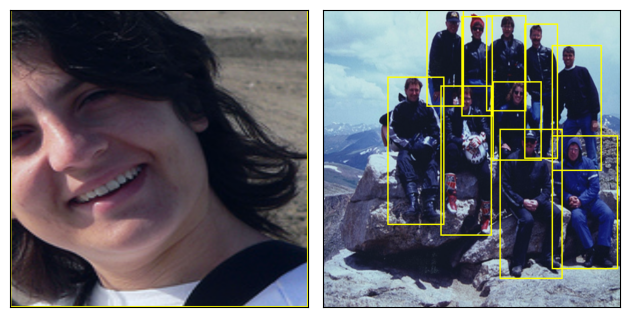

In [148]:
from helpers import plot
ix = 602
samples = []
vis_convert = tv2.ConvertBoundingBoxFormat('XYXY')
for x in range(2):
    i, b = detr_train[ix + x]
    print("----------\n", i, "----------\n", b)
    newbox = vis_convert(b['boxes'])
    samples.append((i, newbox))
    
plot(samples)

In [149]:
batchsize = 16

train_loader = tud.DataLoader(detr_train, batch_size=batchsize, num_workers=cpu_num, shuffle=True)
val_loader = tud.DataLoader(detr_val, num_workers=cpu_num, batch_size=batchsize, shuffle=True)

In [ ]:
def xywh_to_xyxy(boxes):
    boxes[..., 2] = boxes[..., 0] + boxes[..., 2]
    boxes[..., 3] = boxes[..., 1] + boxes[..., 3]
    return boxes

def xywh_to_cxywh(boxes):
    boxes[..., 0] = boxes[..., 0] + boxes[..., 2] // 2
    boxes[..., 1] = boxes[..., 1] + boxes[..., 3] // 2
    return boxes

def cxywh_to_cell_cxywh(boxes, stride):
    batch, slot, _ = boxes.shape
    outs = boxes.clone()
    offset = boxes.clone()
    
    # Now index 0 and 1 are cell positions
    outs[..., 0] = boxes[..., 0] // stride
    outs[..., 1] = boxes[..., 1] // stride
    
    outs[..., 0] * stride
    outs[..., 0] * stride
    return boxes

class YoloLoss(nn.Module):
    def __init__(self, stride, canvas_size, num_classes):  
        super().__init__()
        self.stride = stride
        
        self.num_classes = num_classes
        
        self.w, self. h = canvas_size
        assert (self.w % stride == 0) and (self.h % stride == 0)
        
        self.box_loss = nn.L1Loss()
        self.cl_loss = nn.BCEWithLogitsLoss()
        
        w, h = canvas_size
        assert (w % stride == 0) and (h % stride == 0)
        
    # Convert boxes to be relative to the image cell
    # [cellx, celly, coffsetx, coffsety, width, height]
    def convert_xywh_to_cells(self, boxes):
        as_cxywh = xywh_to_cxywh(boxes.float())
        # print("CXY: ", as_cxywh)
        
        # nc = nearest_corners
        nc = torch.zeros_like(as_cxywh)
        nc[..., 0] = (as_cxywh[..., 0] // self.stride) * self.stride
        nc[..., 1] = (as_cxywh[..., 1] // self.stride) * self.stride
        cell_ix = (nc / self.stride)[..., :2].long()
        # print("Cell IX: ", cell_ix)
        # print("Nearest Corner: ", nc)
        
        # xoffset, yoffset, w, h
        offsets = (as_cxywh - nc)
        # print("Offsets: ", offsets)
        
        # Normalize the offset from nearest cell corner to the stride and
        # normalize the width and height to the canvas size. This places all
        # values between 0 and 1.
        offsets[..., 0] = offsets[..., 0] / self.stride
        offsets[..., 1] = offsets[..., 1] / self.stride
        offsets[..., 2] = offsets[..., 2] / self.w
        offsets[..., 3] = offsets[..., 3] / self.h
        
        return cell_ix, offsets
        
    
    # Boxes in [N, num_cells, 4]
    # * xywh ordering, x & y are the top left corner
    # * num_cells is (canvas_dim / stride)^2 for each stride.
    # Classes are onehot in [N, num_classes]
    def forward(self, pboxes, pclasses, tboxes, tclasses):
        cell_ixs, converted_tgt_box = self.convert_xywh_to_cells(tboxes)

        class_grid = torch.zeros(
            self.h // self.stride,
            self.w // self.stride,
            self.num_classes,
            dtype=torch.float32
        )
        
        box_grid = torch.zeros(
            self.h // self.stride,
            self.w // self.stride,
            4,
            dtype=torch.float32
        )
        
        for ix, cl, bb in zip(cell_ixs, tclasses, converted_tgt_box):
            (y, x) = ix
            class_grid[y, x, :] = cl
            box_grid[y, x, :] = bb
        
        print(class_grid.flatten(0, 2)
        print(box_grid.flatten(0, 2)
        

In [182]:
box = torch.tensor([[200, 300, 40, 50]])

i, b = detr_val[1]
print(b)

l = YoloLoss(320, (640, 640), 20)
# l.convert_norm_xywh_to_cells(b['boxes'])
l(None, None, b['boxes'], b['labels'])

{'boxes': BoundingBoxes([[ 58,  21, 582, 619],
               [ 79, 365,  27, 102]], format=BoundingBoxFormat.XYWH, canvas_size=(640, 640)), 'labels': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]])}
torch.Size([2, 2, 20])
tensor([[[0.0000, 0.0000, 0.0000, 0.0000],
         [0.2875, 0.3000, 0.0422, 0.1594]],

        [[0.0000, 0.0000, 0.0000, 0.0000],
         [0.0906, 0.0312, 0.9094, 0.9672]]])
